In [1]:
import intake
import cf_xarray as cfxr
import cf_xarray.units
import pint_xarray
from pint import application_registry as ureg
import matplotlib.pyplot as plt
from dask.distributed import Client
import logging
import xarray as xr
import numpy as np
import warnings
import glob
import os

from pint import application_registry as ureg
import cartopy.crs as ccrs
import matplotlib.animation as animation

warnings.filterwarnings('ignore')

In [2]:
def compute_salt_volume_average_all_locations(salt,time, area):
    """
    Compute volume-averaged salinity at all horizontal grid points.

    Parameters:
    -----------
    salt : xarray.Dataset
        Dataset containing 'salt' and 'st_edges_ocean' variables.
        Expected shape: (time, st_ocean, yt_ocean, xt_ocean)
    area : xarray.DataArray
        2D horizontal area array with dims ('yt_ocean', 'xt_ocean')

    Returns:
    --------
    salt_volume_average : xarray.DataArray
        2D array of volume-averaged salinity at each horizontal grid point.
        Dims: ('yt_ocean', 'xt_ocean')
    """

    # Use salinity at time=0
    salt_3d = salt.salt.isel(time=time)  # shape: (st_ocean, yt, xt)

    # Compute layer thicknesses (zt) from edges (st_edges_ocean)
    zt = np.diff(salt.st_edges_ocean.values)  # shape: (st_ocean,)

    # Convert zt to a DataArray with st_ocean dimension
    zt_da = xr.DataArray(zt, dims=["st_ocean"], coords={"st_ocean": salt.salt.st_ocean})

    # Broadcast zt to shape (st_ocean, yt_ocean, xt_ocean)
    zt_3d = zt_da.broadcast_like(salt_3d)

    # Broadcast area to shape (st_ocean, yt_ocean, xt_ocean)
    area_3d = area.broadcast_like(salt_3d)

    # Compute volume per layer
    volume = area_3d * zt_3d  # m³

    # Compute salt mass per layer
    salt_mass = salt_3d * volume

    # Sum over vertical to get total salt and total volume
    total_salt = salt_mass.sum(dim="st_ocean")
    total_volume = volume.where(salt_mass != 0).sum(dim="st_ocean")

    # Avoid divide-by-zero by setting total_volume=1 where it's 0 (will return 0 in result)
    salt_volume_average = total_salt / total_volume
    salt_volume_average = salt_volume_average.rename_vars({"area_t": "salt"})
    salt_volume_average = salt_volume_average.where(salt.salt.isel(st_ocean=0, time = 0).notnull())
    return salt_volume_average

In [3]:
def pmask(mesh_mask, pltaxis, lonlat=False):
    """
    Plot landmask for ACCESS-ESM grids using 'mbathy' or 'kmt'.
    """
    bathy = mesh_mask

    lmask = np.ma.masked_where(bathy != 0, bathy)
    lmask.fill_value = 5
    if not lonlat:
        pltaxis.contourf(lmask.filled(), levels=[4.9, 5, 5.1],
                         colors=('#858588', '#858588'), alpha=0.9, linewidths=0.1)
        pltaxis.pcolormesh(lmask.filled())
        pltaxis.pcolormesh(lmask)
    else:
        pltaxis.contourf(mesh['nav_lon'], mesh['nav_lat'], lmask.filled(),
                         levels=[4.9, 5, 5.1], colors=('#858588', '#858588'), alpha=0.9, linewidths=0.1)

    mesh.close()
    return

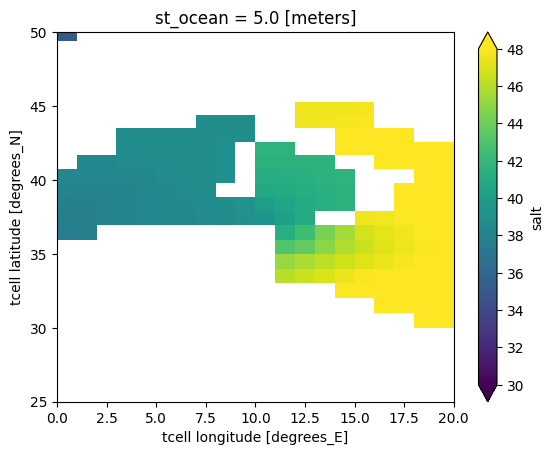

In [4]:
file_list = []
for i in range(831, 849):  # 831 to 848 inclusive
    path = f"/scratch/p66/jxs599/access-esm/archive/AprilSpinUp-AprilSpinUp-56aae814/output{i}/ocean/ocean-3d-salt-1monthly-mean-ym_*.nc"
    matches = glob.glob(path)
    if matches:
        file_list.extend(matches)

salt_jhan = xr.open_mfdataset(file_list, coords="minimal", compat="override", engine="netcdf4")
salt_old = salt_jhan.mean('time').isel(st_ocean=0)
salt_old.salt.plot(xlim=(0,20), ylim=(25,50), vmin=30, vmax=48)

In [5]:
area_2d = xr.open_mfdataset('/scratch/p66/pjb581/access-esm/archive/pi_concentrations_test3-restart-840-35bbe5a7/output060/ocean/ocean-2d-area_t.nc', coords = "minimal", compat="override",engine="netcdf4")

In [6]:
# Create a list of all matching files in output831 to output848
file_list = []
for i in range(831, 849):  # 849 excluded, so up to 848
    path_pattern = f'/g/data/tm70/ek4684/esm16_bathy_tests/archive/output{i}/ocean/ocean-3d-salt-1monthly-mean-ym_*.nc'
    matched_files = glob.glob(path_pattern)
    file_list.extend(matched_files)

# Open all files as one dataset
salt = xr.open_mfdataset(file_list, coords="minimal", compat="override", engine="netcdf4")

In [12]:
salt_avg_list = []
salt_avg_list_old = []

for t in range(216):
    salt_avg = compute_salt_volume_average_all_locations(salt, t, area_2d)
    salt_avg_list.append(salt_avg)
    salt_avg_old = compute_salt_volume_average_all_locations(salt_jhan, t, area_2d)
    salt_avg_list_old.append(salt_avg_old)

# Combine into a single DataArray with time dimension
salt_volume_avg_alltime = xr.concat(salt_avg_list, dim="time")
salt_volume_avg_alltime["time"] = salt.salt.time  # Assign time coordinates

salt_volume_avg_alltime_old = xr.concat(salt_avg_list_old, dim="time")
salt_volume_avg_alltime_old["time"] = salt.salt.time  # Assign time coordinates
salt_difference = salt_volume_avg_alltime - salt_volume_avg_alltime_old

In [26]:
mask_path = '/g/data/vk83/configurations/inputs/access-esm1p5/modern/share/ice/grids/global.1deg/2020.05.19/kmt.nc'

fig, ax = plt.subplots(figsize=(8, 4))

def update(frame):
    ax.clear()
    salt_difference.salt.isel(time=frame).plot(xlim=(0, 20), ylim=(25, 50),ax=ax, add_colorbar=False, cmap='coolwarm')
    ax.set_title(f"Volume-Averaged Salinity - Month {frame+1}")

ani = animation.FuncAnimation(fig, update, frames=216, interval=1200)
plt.close()

In [27]:
from IPython.display import HTML
HTML(ani.to_jshtml())

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>


ValueError: left cannot be >= right

In [ ]:
ani.save("/g/data/tm70/ek4684/ESM_1_6_plots/salt_volume_average_masked.mp4", writer="ffmpeg", dpi=150)

In [8]:
mask =  xr.open_mfdataset('/g/data/vk83/configurations/inputs/access-esm1p5/modern/share/ice/grids/global.1deg/2020.05.19/kmt.nc', coords = "minimal", compat="override",engine="netcdf4")

In [9]:
mask

<xarray.Dataset> Size: 432kB
Dimensions:  (ny: 300, nx: 360)
Dimensions without coordinates: ny, nx
Data variables:
    kmt      (ny, nx) int32 432kB dask.array<chunksize=(300, 360), meta=np.ndarray>

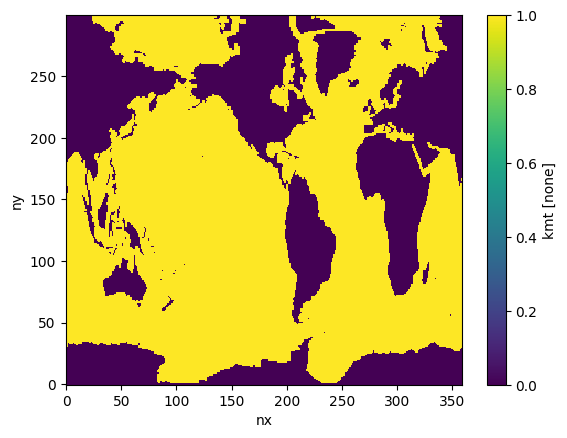

In [10]:
mask.kmt.plot()

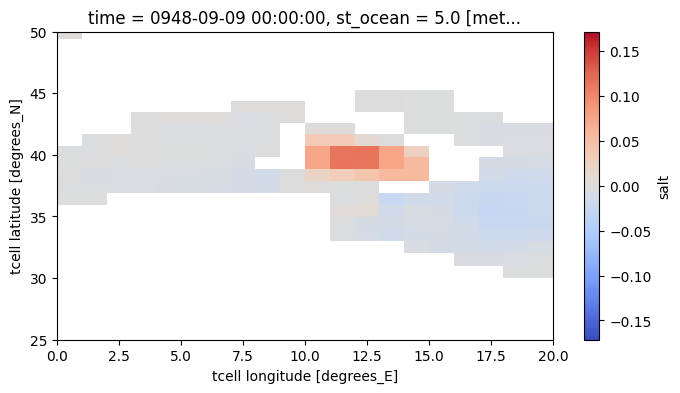

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
salt_difference.salt.isel(time=200).plot(ax=ax,xlim=(0, 20), ylim=(25, 50), add_colorbar=True, cmap='coolwarm')

In [21]:
mask_path = '/g/data/vk83/configurations/inputs/access-esm1p5/modern/share/ice/grids/global.1deg/2020.05.19/kmt.nc'

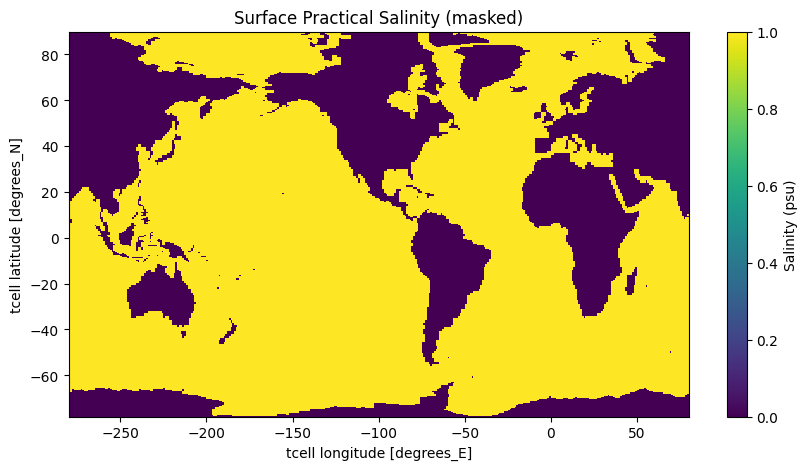

In [37]:
# Mask out invalid values (e.g., less than or equal to -10)
salt_clean = salt.salt > -10

# Select a specific time index or depth if needed
# Example: surface salinity at first time step
salt_plot = salt_clean.isel(time=0, st_ocean=0)

# Plot the data
plt.figure(figsize=(10, 5))
salt_plot.plot(
    x='xt_ocean', y='yt_ocean',
    cmap='viridis',  # or any other colormap
    cbar_kwargs={'label': 'Salinity (psu)'}
)
plt.title("Surface Practical Salinity (masked)")
plt.show()

In [33]:
salt_plot

<xarray.Dataset> Size: 3MB
Dimensions:         (yt_ocean: 300, xt_ocean: 360, nv: 2, st_edges_ocean: 51)
Coordinates:
  * xt_ocean        (xt_ocean) float64 3kB -279.5 -278.5 -277.5 ... 78.5 79.5
  * yt_ocean        (yt_ocean) float64 2kB -77.88 -77.63 -77.38 ... 89.32 89.77
    st_ocean        float64 8B 5.0
    time            object 8B 0932-01-09 12:00:00
  * st_edges_ocean  (st_edges_ocean) float64 408B 0.0 10.0 ... 5.665e+03 6e+03
  * nv              (nv) float64 16B 1.0 2.0
Data variables:
    salt            (yt_ocean, xt_ocean) float32 432kB dask.array<chunksize=(150, 180), meta=np.ndarray>
    average_T1      (yt_ocean, xt_ocean) float32 432kB dask.array<chunksize=(150, 180), meta=np.ndarray>
    average_T2      (yt_ocean, xt_ocean) float32 432kB dask.array<chunksize=(150, 180), meta=np.ndarray>
    average_DT      (yt_ocean, xt_ocean) float32 432kB dask.array<chunksize=(150, 180), meta=np.ndarray>
    time_bnds       (yt_ocean, xt_ocean, nv) float32 864kB dask.array<chunksize=(150, 180, 2), meta=np.ndarray>
Attributes:
    filename:   ocean-3d-salt-1monthly-mean-ym_0932_01.nc
    title:      ACCESS-ESM_CMIP6
    grid_type:  regular
    grid_tile:  N/A

In [46]:
salt_mask = (~salt_difference.isel(time = 0).salt.notnull())

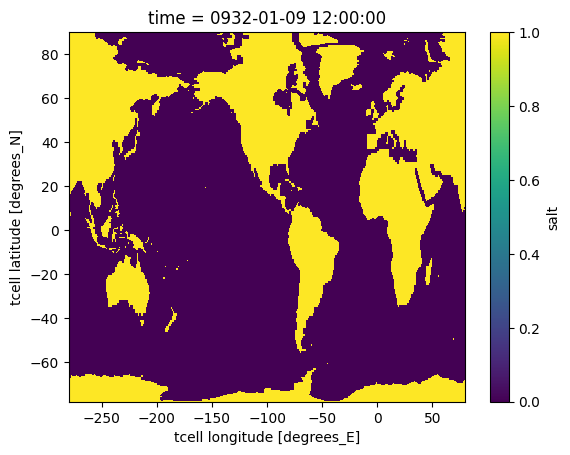

In [47]:
salt_mask.plot()

In [21]:
mask_path = '/g/data/vk83/configurations/inputs/access-esm1p5/modern/share/ice/grids/global.1deg/2020.05.19/kmt.nc'

fig, ax = plt.subplots(figsize=(8, 4))

def update(frame):
    ax.clear()
    salt_difference.salt.isel(time=frame).plot(ax=ax,xlim=(0, 20), ylim=(25, 50), cmap='coolwarm')
    ax.set_title(f"Volume-Averaged Salinity - Month {frame+1}")

ani = animation.FuncAnimation(fig, update, frames=216, interval=1200)
plt.close()

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>


ValueError: left cannot be >= right